In [1]:
!pip install gdown

In [3]:
!gdown 1NZ_CeBOzh0yZGd4TMC3GyU9rZwf4MHNg


Downloading...
From (original): https://drive.google.com/uc?id=1NZ_CeBOzh0yZGd4TMC3GyU9rZwf4MHNg
From (redirected): https://drive.google.com/uc?id=1NZ_CeBOzh0yZGd4TMC3GyU9rZwf4MHNg&confirm=t&uuid=c1e53035-8f5f-4734-8b9f-4a1bdf2d23d8
To: /kaggle/working/merged_df_copy.csv.zip
100%|█████████████████████████████████████████| 734M/734M [00:06<00:00, 109MB/s]


In [4]:
import pandas as pd

# Adjust the path to your file's location
file_path = '/kaggle/working/merged_df_copy.csv.zip'
merged_df = pd.read_csv(file_path,  compression='zip')
print(merged_df.head())


<ipython-input-4-696a51af28e6>:5: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv(file_path,  compression='zip')


    event_type      begin_date_time cz_timezone        end_date_time  \
0        Flood  2012-10-29 12:30:00       EST-5  2012-10-29 22:30:00   
1   Heavy Rain  2014-05-15 14:00:00       EST-5  2014-05-16 17:00:00   
2   Heavy Rain  2016-10-08 10:00:00       EST-5  2016-10-09 11:00:00   
3  Flash Flood  2014-09-21 23:14:00       MST-7  2014-09-22 02:00:00   
4  Flash Flood  2014-09-27 16:00:00       MST-7  2014-09-27 23:00:00   

   begin_lat  begin_lon  end_lat  end_lon  extreme begin_date_utc  ...  \
0      37.84     -75.48    37.70   -75.62        0     2012-10-29  ...   
1      37.84     -75.48    37.82   -75.62        0     2014-05-15  ...   
2      37.84     -75.48    37.84   -75.48        0     2016-10-08  ...   
3      32.90    -107.34    32.82  -107.34        0     2014-09-22  ...   
4      39.70    -110.88    39.54  -110.92        1     2014-09-27  ...   

                        prev_72h_wind_direction_100m  \
0  [75.5559310913086, 77.90525817871094, 78.54128...   
1  [198.64

In [5]:
meteo_cols = [col for col in merged_df.columns if col.startswith("prev_72h")]
meteo_cols.remove("prev_72h_weather")
meteo_cols.remove("prev_72h_weather_code")
meteo_cols.remove("prev_72h_snow_depth")
meteo_cols.remove("prev_72h_snowfall")

In [6]:

import numpy as np
from tqdm import tqdm
import ast
for col in tqdm(meteo_cols):
    merged_df[col] = merged_df[col].apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else np.array(x))

100%|██████████| 27/27 [02:41<00:00,  5.97s/it]


In [7]:
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import multiprocessing as mp
import os

# Configuration
N_JOBS = min(os.cpu_count(), 8)  # Limit cores for memory safety
CHUNK_SIZE = 100  # Optimal for most datasets

# Feature calculation functions
def calculate_statistical(values):
    return {
        'mean': np.nanmean(values),
        'median': np.nanmedian(values),
        'min': np.nanmin(values),
        'max': np.nanmax(values),
        'std': np.nanstd(values),
        'variance': np.nanvar(values),
        'skewness': pd.Series(values).skew(),
        'kurtosis': pd.Series(values).kurt()
    }

def calculate_temporal(values):
    features = {}
    if len(values) >= 24:
        slope, intercept = np.polyfit(range(len(values)), values, 1)
        features.update({
            'trend_slope': slope,
            'trend_intercept': intercept,
            'lag_24h': values[-24],
            'lag_48h': values[-48] if len(values) >= 48 else np.nan,
            'lag_72h': values[-72] if len(values) >= 72 else np.nan
        })
    else:
        features.update({k: np.nan for k in ['trend_slope', 'trend_intercept', 
                                           'lag_24h', 'lag_48h', 'lag_72h']})
    return features

def calculate_rolling(values):
    features = {}
    if len(values) >= 24:
        s = pd.Series(values)
        window = s.rolling(24)
        features.update({
            'rolling_mean_24h': window.mean().iloc[-1],
            'rolling_std_24h': window.std().iloc[-1],
            'rolling_max_24h': window.max().iloc[-1],
            'rolling_min_24h': window.min().iloc[-1]
        })
    else:
        features.update({f'rolling_{stat}_24h': np.nan 
                       for stat in ['mean', 'std', 'max', 'min']})
    return features

def calculate_domain(col_name, values):
    features = {}
    if 'temperature' in col_name:
        features['temp_diff'] = np.nanmax(values) - np.nanmin(values)
    elif 'precipitation' in col_name:
        features.update({
            'total_precip': np.nansum(values),
            'precip_hours': sum(x > 0 for x in values)
        })
    elif 'humidity' in col_name:
        features['humidity_range'] = np.nanmax(values) - np.nanmin(values)
    return features

# Main processing function
def process_row(row, columns):
    features = {}
    features['original_index'] = row.name
    for col in columns:
        values = row[col]
        # Statistical features
        stats = calculate_statistical(values)
        features.update({f'{col}_{k}': v for k, v in stats.items()})
        
        # Temporal features
        temporal = calculate_temporal(values)
        features.update({f'{col}_{k}': v for k, v in temporal.items()})
        
        # Rolling features
        rolling = calculate_rolling(values)
        features.update({f'{col}_{k}': v for k, v in rolling.items()})
        
        # Domain-specific features
        domain = calculate_domain(col, values)
        features.update({f'{col}_{k}': v for k, v in domain.items()})
    
    return features

# Parallel executor
def parallel_feature_extraction(df, columns):
    rows = [row for _, row in df.iterrows()]
    
    # Process in parallel with progress tracking
    results = Parallel(n_jobs=N_JOBS, batch_size=CHUNK_SIZE)(
        delayed(process_row)(row, columns)
        for row in tqdm(rows, desc='Processing rows', position=0)
    )
    
    return pd.DataFrame(results)

# Sample data generation and execution
if __name__ == '__main__':
    # Create test data (1000 rows × 3 columns)

    all_featires = merged_df[meteo_cols].copy()
    
    # Execute feature extraction
    final_df = parallel_feature_extraction(all_featires, meteo_cols)
    final_df = final_df.set_index('original_index')
    # Results verification
    print(f"\n✅ Processing complete!")
    print(f"Final DataFrame shape: {final_df.shape}")
    print("Sample features:")
    print(final_df.iloc[0, :5].to_string())  # Show first 5 features of first row


Processing rows:   0%|          | 0/35137 [00:00<?, ?it/s]


✅ Processing complete!
Final DataFrame shape: (35137, 468)
Sample features:
prev_72h_temperature_2m_mean      16.049861
prev_72h_temperature_2m_median    15.682500
prev_72h_temperature_2m_min       12.032500
prev_72h_temperature_2m_max       20.932499
prev_72h_temperature_2m_std        2.148985


In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Assuming final_df is your DataFrame of shape (35137, 468)
# It's a good idea to handle missing values; here I'm filling them with zeros as an example.
final_df_filled = final_df.fillna(0)

# Standardization: transform data to have mean 0 and standard deviation 1.
scaler_standard = StandardScaler()
standardized_data = scaler_standard.fit_transform(final_df_filled)
standardized_df = pd.DataFrame(standardized_data, index=final_df_filled.index, columns=final_df_filled.columns)

# Normalization: scale data so that features are in the range [0, 1].
scaler_minmax = MinMaxScaler()
normalized_data = scaler_minmax.fit_transform(final_df_filled)
normalized_df = pd.DataFrame(normalized_data, index=final_df_filled.index, columns=final_df_filled.columns)

# Display first 5 rows of each result for verification.
print("Standardized Data (first 5 rows):")
print(standardized_df.head())

print("\nNormalized Data (first 5 rows):")
print(normalized_df.head())


Standardized Data (first 5 rows):
                prev_72h_temperature_2m_mean  prev_72h_temperature_2m_median  \
original_index                                                                 
0                                  -0.290244                       -0.307167   
1                                   0.323696                        0.336805   
2                                   0.252043                        0.300847   
3                                   0.413981                        0.414147   
4                                   0.146613                        0.118639   

                prev_72h_temperature_2m_min  prev_72h_temperature_2m_max  \
original_index                                                             
0                                 -0.045728                    -0.539383   
1                                  0.426424                     0.340896   
2                                  0.668120                    -0.221128   
3                        

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Assume normalized_df is your normalized DataFrame of shape (35137, 468)
# If needed, fill or drop any remaining missing values beforehand.
data = normalized_df.copy()

# ---------------------------
# PCA Dimensionality Reduction
# ---------------------------
# We'll reduce the data to 2 principal components.
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

# Create a DataFrame for PCA results.
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=data.index)




PCA explained variance ratio: [0.24015939 0.131355  ]


<ipython-input-12-c9923bbd3e99>:22: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method='average')


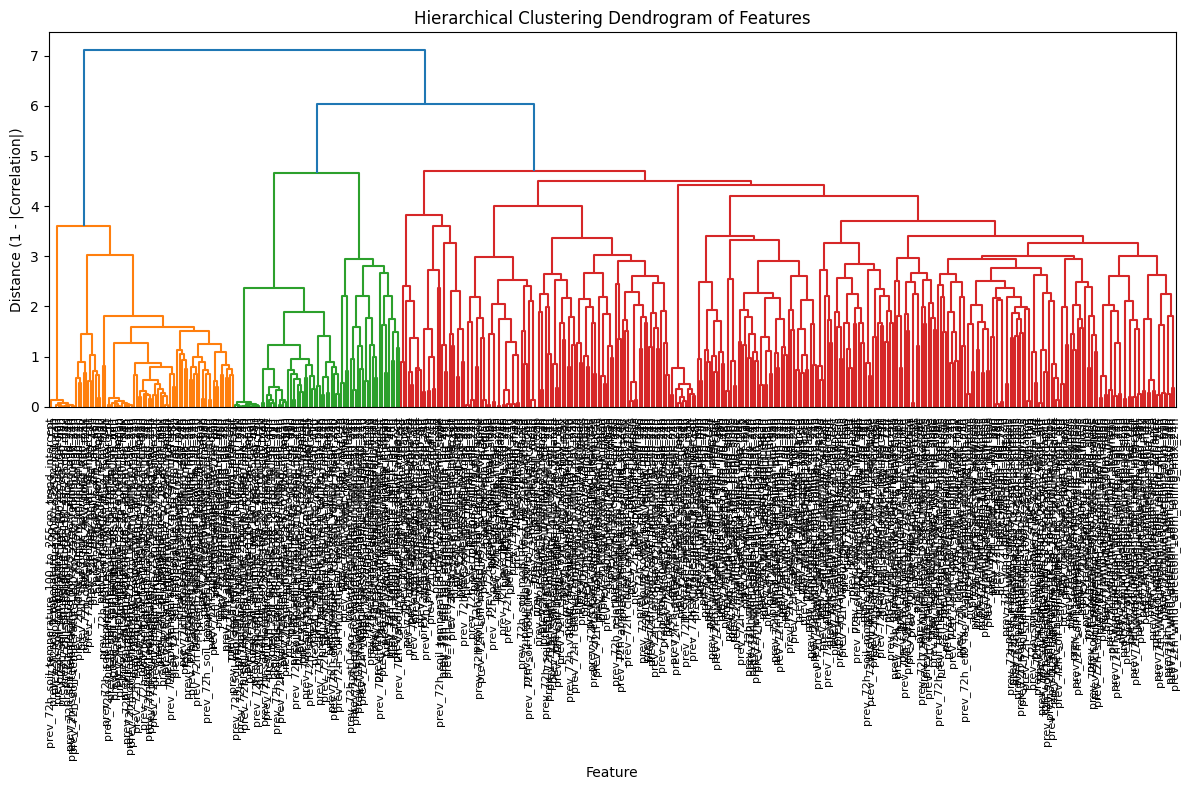

Number of original features: 468
Number of features after dropping highly correlated ones: 143
Dropped features:
['prev_72h_temperature_2m_median', 'prev_72h_temperature_2m_min', 'prev_72h_temperature_2m_max', 'prev_72h_temperature_2m_variance', 'prev_72h_temperature_2m_trend_intercept', 'prev_72h_temperature_2m_lag_24h', 'prev_72h_temperature_2m_lag_48h', 'prev_72h_temperature_2m_lag_72h', 'prev_72h_temperature_2m_rolling_mean_24h', 'prev_72h_temperature_2m_rolling_max_24h', 'prev_72h_temperature_2m_rolling_min_24h', 'prev_72h_temperature_2m_temp_diff', 'prev_72h_relative_humidity_2m_median', 'prev_72h_relative_humidity_2m_min', 'prev_72h_relative_humidity_2m_std', 'prev_72h_relative_humidity_2m_variance', 'prev_72h_relative_humidity_2m_skewness', 'prev_72h_relative_humidity_2m_trend_intercept', 'prev_72h_relative_humidity_2m_rolling_mean_24h', 'prev_72h_relative_humidity_2m_rolling_max_24h', 'prev_72h_relative_humidity_2m_rolling_min_24h', 'prev_72h_relative_humidity_2m_humidity_rang

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

# Assuming final_df is your DataFrame with shape (35137, 468)
# (Make sure it's numeric and handle missing values if needed)
final_df_filled = final_df.fillna(0)

# --------------------------------------
# Part 1: Visualizing Feature Clusters
# --------------------------------------
# Compute absolute correlation matrix
corr_matrix = final_df_filled.corr().abs()

# Compute the distance matrix as (1 - correlation)
# For hierarchical clustering, we need to convert our similarity measure into a distance measure.
distance_matrix = 1 - corr_matrix

# Generate linkage matrix using average linkage method
linkage_matrix = linkage(distance_matrix, method='average')

# Plot dendrogram – note that labels might be overlapped due to a large number of features
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=corr_matrix.columns, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram of Features")
plt.xlabel("Feature")
plt.ylabel("Distance (1 - |Correlation|)")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Part 2: Automatic Feature Elimination by Correlation
# -------------------------------------------------
def drop_highly_correlated_features(df, correlation_threshold=0.95):
    """
    Drops features that are highly correlated. For each pair of features with a correlation
    above the threshold, one feature is removed.
    
    Args:
        df: DataFrame containing the features.
        correlation_threshold: Threshold above which features are considered redundant.
    
    Returns:
        A tuple (df_reduced, dropped_features) where:
         - df_reduced is the DataFrame after dropping features.
         - dropped_features is a list of feature names that were dropped.
    """
    corr_matrix = df.corr().abs()
    # Select the upper triangle of the correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with a correlation greater than the specified threshold
    drop_cols = [column for column in upper_tri.columns if any(upper_tri[column] > correlation_threshold)]
    
    # Drop these features from the DataFrame
    df_reduced = df.drop(columns=drop_cols)
    return df_reduced, drop_cols

# Apply the function
reduced_df, dropped_features = drop_highly_correlated_features(final_df_filled, correlation_threshold=0.75)

print("Number of original features:", final_df_filled.shape[1])
print("Number of features after dropping highly correlated ones:", reduced_df.shape[1])
print("Dropped features:")
print(dropped_features)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import RandomizedSearchCV
# -------------------------
# 1. Data Preparation
# -------------------------
# Assume reduced_df is your feature DataFrame and that it contains a target column "target".
# Replace 'target' with your actual target column name if different.
X = reduced_df.copy()
y = merged_df["extreme"].values

# Train-test split with stratification (90% training, 10% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

print("Train and test split:")
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("Target distribution in training set:")
# print(y_train.value_counts(normalize=True))
print("Target distribution in test set:")
# print(y_test.value_counts(normalize=True))

# -------------------------
# 2. Model Training with Hyperparameter Tuning
# -------------------------
# Define cross-validation strategy: StratifiedKFold with 5 splits.
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Define models and hyperparameter grids.
models = {
    # 'Logistic Regression': {
    #     'model': LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
    #     'params': {
    #         'C': [0.01, 0.1, 1, 10],
    #         'penalty': ['l2']
    #     }
    # },
    'Decision Tree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },
    # 'Gradient Boosting': {
    #     'model': GradientBoostingClassifier(random_state=42),
    #     'params': {
    #         'n_estimators': [50, 100, 150],
    #         'learning_rate': [0.01, 0.1, 0.2],
    #         'max_depth': [3, 5, 7]
    #     }
    # },
    'Support Vector Machine': {
        'model': SVC(class_weight='balanced', probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear']
        }
    }
}

results = {}
print("\nStarting model training and hyperparameter tuning with cross validation:")

# Iterate over models with a progress bar.
for model_name, config in tqdm(models.items(), desc="Models", total=len(models)):
    print(f"\n----- Training {model_name} -----")
    
    grid = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        scoring='roc_auc',  # Using ROC-AUC is common for imbalanced data.
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1,
        n_iter=10
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    print(f"Best parameters for {model_name}: {grid.best_params_}")
    print(f"Best cross validated ROC-AUC for {model_name}: {grid.best_score_:.4f}")
    
    # Evaluate on the test set.
    y_pred = best_model.predict(X_test)
    # Some models support predict_proba; use it for AUC.
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc = None
    
    print(f"\nEvaluation metrics for {model_name} on the test set:")
    print(classification_report(y_test, y_pred, digits=4))
    if auc is not None:
        print(f"Test ROC-AUC: {auc:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    results[model_name] = {
        'best_model': best_model,
        'best_params': grid.best_params_,
        'best_cv_score': grid.best_score_,
        'classification_report': classification_report(y_test, y_pred, digits=4, output_dict=True),
        'confusion_matrix': cm,
        'test_auc': auc
    }

print("\nAll models have been trained and evaluated.")


In [1]:
import pandas as pd

merged_df = pd.read_csv(r"/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv")

<ipython-input-1-36c12f2d873d>:3: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv(r"/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv")


In [2]:
meteo_cols = [col for col in merged_df.columns if col.startswith("prev_72h")]
meteo_cols.remove("prev_72h_weather")
meteo_cols.remove("prev_72h_weather_code")
meteo_cols.remove("prev_72h_snow_depth")
meteo_cols.remove("prev_72h_snowfall")

In [3]:

import numpy as np
from tqdm import tqdm
import ast
for col in tqdm(meteo_cols):
    merged_df[col] = merged_df[col].apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else np.array(x))

100%|██████████| 27/27 [02:10<00:00,  4.85s/it]


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df[meteo_cols], y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset
oversample = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = oversample.fit_resample(X_train,y_train_bin)


X_resampled = np.stack(X_resampled[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_resampled)/len(y_resampled))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_resampled.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_resampled))
# Scale the data
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_resampled = X_resampled.reshape(-1, X_resampled.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_resampled.shape)
X_resampled = scaler.fit_transform(X_resampled)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_resampled = X_resampled.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_resampled.shape)
print("y_train shape:", y_resampled.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_resampled = X_resampled.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_resampled.shape[1]  # should be 72
num_features  = X_resampled.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






# --- Shared Conv Block 1 ---
conv1 = Conv1D(filters=64, kernel_size=3, padding='same')(input_layer)
conv1 = BatchNormalization()(conv1)
conv1 = LeakyReLU(alpha=0.01)(conv1)
conv1 = MaxPooling1D(pool_size=2)(conv1)
conv1 = Dropout(0.3)(conv1)

# --- Shared Conv Block 2 ---
conv2 = Conv1D(filters=128, kernel_size=5, padding='same')(conv1)
conv2 = BatchNormalization()(conv2)
conv2 = LeakyReLU(alpha=0.01)(conv2)
conv2 = Dropout(0.3)(conv2)

# --- Residual Connection from Conv Block 1 ---
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(conv1)
shortcut = BatchNormalization()(shortcut)
res = Add()([conv2, shortcut])

# --- Shared Conv Block 3 ---
conv3 = Conv1D(filters=128, kernel_size=7, padding='same')(res)
conv3 = BatchNormalization()(conv3)
conv3 = LeakyReLU(alpha=0.01)(conv3)
conv3 = Dropout(0.3)(conv3)

# --- Shared LSTM Sequence Processing Block ---
x = Bidirectional(LSTM(128, return_sequences=True))(conv3)
x = Dropout(0.4)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.4)(x)

# --- Shared Attention Mechanism ---
# Using built-in Keras Attention layer (self-attention)
attn_out = Attention()([x, x])
# Aggregate attended features into a fixed-size vector
shared_features = GlobalAveragePooling1D()(attn_out)

# --- Event Type Classification Head ---
event_branch = Dense(64)(shared_features)
event_branch = BatchNormalization()(event_branch)
event_branch = LeakyReLU(alpha=0.01)(event_branch)
event_branch = Dropout(0.5)(event_branch)
event_output = Dense(3, activation='softmax', name='event_type')(event_branch)

# --- Extreme Event Classification Head ---
extreme_branch = Dense(64)(shared_features)
extreme_branch = BatchNormalization()(extreme_branch)
extreme_branch = LeakyReLU(alpha=0.01)(extreme_branch)
extreme_branch = Dropout(0.5)(extreme_branch)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(extreme_branch)

# --- Create and Compile the Multi-task Model ---
model = Model(inputs=input_layer, outputs=extreme_output)

optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
# model.compile(optimizer=optimizer,
#               loss={'event_type': 'categorical_crossentropy', 'extreme': 'binary_crossentropy'},
#               metrics={'event_type': ['accuracy'], 'extreme': [tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]})

model.compile(optimizer=optimizer,
              loss={'extreme': 'binary_crossentropy'},
              metrics={'extreme': [tf.keras.metrics.Accuracy(name='accuracy'), tf.keras.metrics.Precision(), tf.keras.metrics.Recall(),  tf.keras.metrics.AUC(name='roc_auc'), tf.keras.metrics.AUC(curve='PR', name='pr_auc') ]})

model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# --- Class Weights ---
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',   # This option adjusts weights inversely proportional to class frequencies in the input data
    classes=np.unique(y_resampled),  # List of unique class labels
    y=y_resampled  # Your target variable (e.g., labels)
)

# Convert class_weights to a dictionary format
class_weight = dict(zip(np.unique(y_resampled), class_weights))
# --- Train the Model ---
epochs = 50
batch_size = 256
print("y resampe shape", y_resampled.shape)
history_1 = model.fit(X_resampled,  y_resampled,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2,
                    callbacks=[early_stopping, reduce_lr],
                    validation_data=(X_validation, y_validation_bin),
                    class_weight=class_weight,
                    verbose=1)




peecentage of positice instance in training data:  0.5
percentage of positice instance in test data:  0.09846328969834946
percentage of positice instance in validation data:  0.0983635716826752
y resampled shape: (40546,)
Class distribution after oversampling: Counter({0: 20273, 1: 20273})
X resampled shape before scaling: (1094742, 72)
X_train shape: (40546, 27, 72)
y_train shape: (40546,)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 72, 27)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 72, 64)         │          5,248 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 72, 64)         │            256 │ conv1d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu (LeakyReLU)   │ (None, 72, 64)         │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 36, 64)         │              0 │ leaky_re_lu[0][0]      │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 36, 64)         │              0 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 36, 128)        │         41,088 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 36, 128)        │            512 │ conv1d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU) │ (None, 36, 128)        │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 36, 128)        │          8,320 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 36, 128)        │              0 │ leaky_re_lu_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 36, 128)        │            512 │ conv1d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 36, 128)        │              0 │ dropout_1[0][0],       │
│                           │                        │                │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 36, 128)        │        114,816 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 36, 128)        │            512 │ conv1d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU) │ (None, 36, 128)        │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)  

 Total params: 607,361 (2.32 MB)

 Trainable params: 606,337 (2.31 MB)

 Non-trainable params: 1,024 (4.00 KB)

y resampe shape (40546,)
Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.0000e+00 - loss: 0.7891 - pr_auc: 0.5479 - precision: 0.5456 - recall: 0.3914 - roc_auc: 0.5547 - val_accuracy: 0.0000e+00 - val_loss: 0.6446 - val_pr_auc: 0.1171 - val_precision: 0.1227 - val_recall: 0.0362 - val_roc_auc: 0.5585 - learning_rate: 1.0000e-04
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.0000e+00 - loss: 0.7227 - pr_auc: 0.5972 - precision: 0.5773 - recall: 0.5131 - roc_auc: 0.6011 - val_accuracy: 0.0000e+00 - val_loss: 0.5701 - val_pr_auc: 0.1484 - val_precision: 0.1813 - val_recall: 0.1790 - val_roc_auc: 0.6133 - learning_rate: 1.0000e-04
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.0000e+00 - loss: 0.6944 - pr_auc: 0.6191 - precision: 0.5951 - recall: 0.5695 - roc_auc: 0.6313 - val_accuracy: 0.0000e+00 - val_loss: 0.5064 - val_pr_auc: 0.1823 - val_precision: 0.1797 - val_recall: 0.3291 - val_roc_auc: 0.6569 - learning_rate: 1.0000e-04

220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Test Accuracy: 0.8021
Test Precision: 0.2075
Test Recall: 0.3584
Test F1-Score: 0.2629
Test ROC AUC: 0.6789


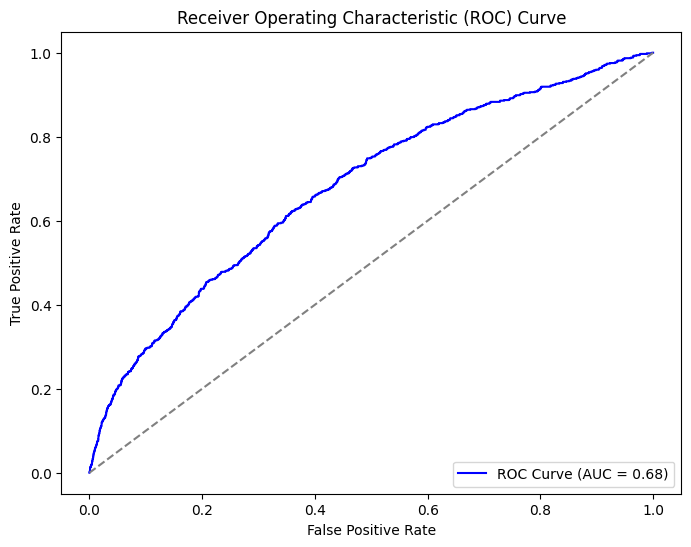

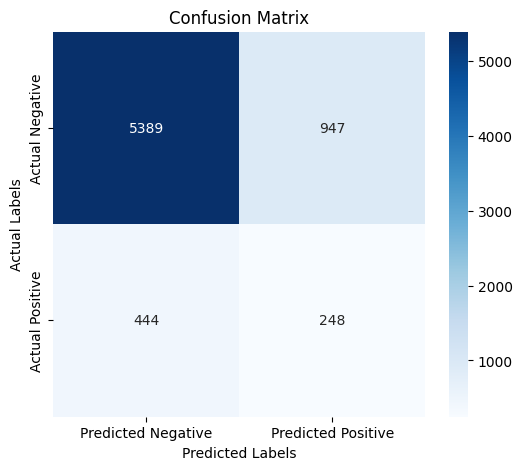

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict(X_test).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)

# 6. Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)

# 8. Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# --------------------------
# Enhanced Temporal Processing
# --------------------------
def build_temporal_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Positional Encoding for Sequence Awareness
    x = PositionalEncoding(sequence_length=input_shape[0], 
                          d_model=input_shape[1])(inputs)
    
    # Multi-scale Dilated Convolutions
    for dilation in [1, 2, 4, 8, 16]:
        x = wavenet_res_block(x, filters=64, dilation_rate=dilation)
    
    # Temporal Attention
    x = layers.MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
    
    # Temporal Feature Aggregation
    x = layers.GlobalAveragePooling1D()(x)
    
    # Uncertainty-aware Prediction
    x = layers.Dropout(0.3)(x, training=True)  # MC Dropout
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return Model(inputs, outputs)

# --------------------------
# Custom Components
# --------------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()
        self.pos_encoding = self.positional_encoding(sequence_length, d_model)
        
    def positional_encoding(self, length, depth):
        depth = depth/2
        positions = tf.range(length, dtype=tf.float32)[:, tf.newaxis]
        depths = tf.range(depth, dtype=tf.float32)[tf.newaxis, :]/depth
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        return tf.expand_dims(tf.concat([tf.sin(angle_rads), 
                                       tf.cos(angle_rads)], axis=-1), axis=0)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

def wavenet_res_block(x, filters, dilation_rate):
    # Gated activation unit
    tanh = layers.Conv1D(filters, 3, padding='causal', 
                       dilation_rate=dilation_rate)(x)
    sigmoid = layers.Conv1D(filters, 3, padding='causal',
                          dilation_rate=dilation_rate)(x)
    z = layers.Multiply()([tf.tanh(tanh), tf.sigmoid(sigmoid)])
    
    # Skip connection
    z = layers.Conv1D(filters, 1)(z)
    return layers.Add()([x, z])

# --------------------------
# Focal Loss Implementation
# --------------------------
def focal_loss(gamma=3.0, alpha=0.25):
    def loss(y_true, y_pred):
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        return -tf.reduce_mean(alpha * (1 - pt)**gamma * tf.math.log(pt))
    return loss

# --------------------------
# Model Compilation
# --------------------------
model = build_temporal_model(input_shape=(72, 27))  # 120 timesteps x 12 features

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=focal_loss(),  # Switch to binary_crossentropy for balanced classes
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='acc'),
        tf.keras.metrics.Precision(name='prec'),
        tf.keras.metrics.Recall(name='rec'),
        tf.keras.metrics.AUC(name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc')
    ]
)

model.summary()

ValueError: Exception encountered when calling PositionalEncoding.call().

[1mCould not automatically infer the output shape / dtype of 'positional_encoding_1' (of type PositionalEncoding). Either the `PositionalEncoding.call()` method is incorrect, or you need to implement the `PositionalEncoding.compute_output_spec() / compute_output_shape()` method. Error encountered:

Dimensions must be equal, but are 27 and 28 for '{{node add}} = AddV2[T=DT_FLOAT](Placeholder, strided_slice_1)' with input shapes: [?,72,27], [1,72,28].[0m

Arguments received by PositionalEncoding.call():
  • args=('<KerasTensor shape=(None, 72, 27), dtype=float32, sparse=False, name=keras_tensor_37>',)
  • kwargs=<class 'inspect._empty'>